Практическое занятие 11: Задача регрессии (прогнозирование стоимости недвижимости)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
import category_encoders as ce
import xgboost as xgb

Шаг 1-3

In [2]:
df = pd.read_csv('all_v2.csv', parse_dates=['date'])
df = df[df['region'] == 2661].copy()
df = df[(df['area'] >= 20) & (df['area'] <= 200)]
df = df[(df['kitchen_area'] >= 6) & (df['kitchen_area'] <= 30)]
df = df[(df['price'] >= 1_500_000) & (df['price'] <= 50_000_000)]
df['rooms'] = df['rooms'].replace([-1, -2], 0)

Шаг 4

In [3]:
df['floor_ratio'] = df['level'] / df['levels'].replace(0, np.nan)
df['floor_ratio'].fillna(0, inplace=True)
df['is_first'] = (df['level'] == 1).astype(int)
df['is_last'] = (df['level'] == df['levels']).astype(int)
df['ratio'] = df['kitchen_area'] / df['area']
df.loc[df['rooms'] == 0, 'ratio'] = df.loc[df['rooms'] == 0, 'area']

Шаг 5 

In [20]:
# Убеждаемся, что столбец 'date' остаётся в X
X = df.drop(columns=['price', 'time'])   # удаляем только цену и время, ДАТУ ОСТАВЛЯЕМ
y = df['price']

# Сортируем по дате (от старых к новым)
X_sorted = X.sort_values('date')
y_sorted = y.loc[X_sorted.index]

# Определяем точку разделения: первые 80% данных по времени
split_idx = int(0.8 * len(X_sorted))
X_train = X_sorted.iloc[:split_idx].copy()
X_test  = X_sorted.iloc[split_idx:].copy()
y_train = y_sorted.iloc[:split_idx].copy()
y_test  = y_sorted.iloc[split_idx:].copy()

Шаг 6

In [21]:
max_date_train = X_train['date'].max()   # только из train
X_train['days_since_listed'] = (max_date_train - X_train['date']).dt.days
X_test['days_since_listed']  = (max_date_train - X_test['date']).dt.days

# Удаляем исходную дату (она больше не нужна)
X_train = X_train.drop(columns=['date'])
X_test  = X_test.drop(columns=['date'])

Шаг 7

In [22]:
cat_features = ['region', 'building_type', 'object_type']
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

encoder = ce.BinaryEncoder(cols=cat_features, return_df=True)
X_train_encoded = encoder.fit_transform(X_train[cat_features])
X_test_encoded  = encoder.transform(X_test[cat_features])

X_train = pd.concat([X_train.drop(columns=cat_features), X_train_encoded], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_features),  X_test_encoded],  axis=1)

Шаг 8

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train!
X_test_scaled  = scaler.transform(X_test)        # transform

Шаг 9

In [24]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# XGBoost без случайности
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    colsample_bylevel=1.0,
    colsample_bynode=1.0,
    random_state=None
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=1.0, colsample_bynode=1.0, colsample_bytree=1.0,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, random_state=None, ...)

Шаг 10 (стандартизировать необязательно)

In [25]:
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge  = ridge.predict(X_test_scaled)
y_train_pred_xgb   = xgb_model.predict(X_train)
y_test_pred_xgb    = xgb_model.predict(X_test)

Шаг 11

In [27]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print("=== Ridge ===")
print(f"Train: RMSLE={rmsle(y_train, y_train_pred_ridge):.4f}, R2={r2_score(y_train, y_train_pred_ridge):.4f}, MAE={mean_absolute_error(y_train, y_train_pred_ridge):.2f}")
print(f"Test:  RMSLE={rmsle(y_test, y_test_pred_ridge):.4f}, R2={r2_score(y_test, y_test_pred_ridge):.4f}, MAE={mean_absolute_error(y_test, y_test_pred_ridge):.2f}")

print("\n=== XGBoost ===")
print(f"Train: RMSLE={rmsle(y_train, y_train_pred_xgb):.4f}, R2={r2_score(y_train, y_train_pred_xgb):.4f}, MAE={mean_absolute_error(y_train, y_train_pred_xgb):.2f}")
print(f"Test:  RMSLE={rmsle(y_test, y_test_pred_xgb):.4f}, R2={r2_score(y_test, y_test_pred_xgb):.4f}, MAE={mean_absolute_error(y_test, y_test_pred_xgb):.2f}")

=== Ridge ===
Train: RMSLE=0.4657, R2=0.7003, MAE=1555356.88
Test:  RMSLE=0.3073, R2=0.6155, MAE=2102958.14

=== XGBoost ===
Train: RMSLE=0.1800, R2=0.8738, MAE=935286.63
Test:  RMSLE=0.2427, R2=0.7539, MAE=1754209.32


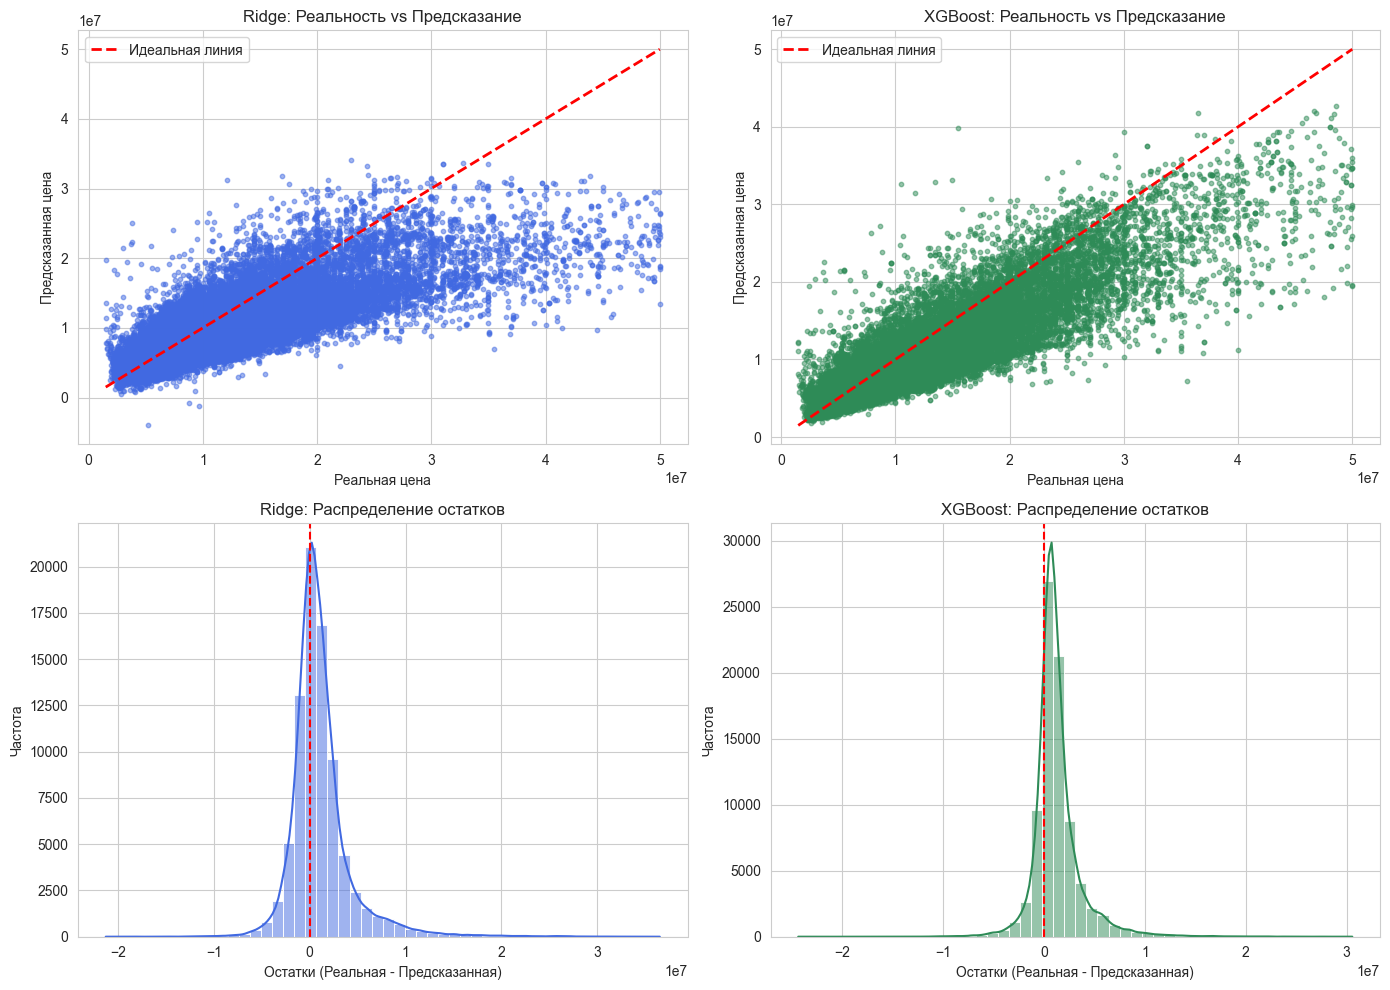


Сравнительная диаграмма метрик (тестовая выборка):


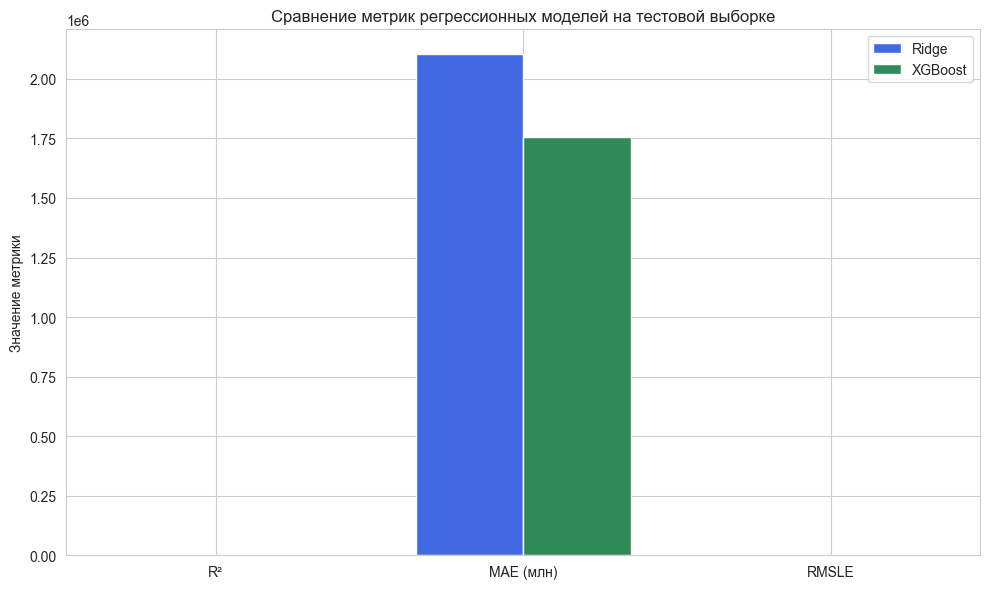

In [28]:
# ====================== ВИЗУАЛИЗАЦИЯ МОДЕЛЕЙ ======================
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля и русского шрифта (если нужен)
plt.rcParams['font.family'] = 'DejaVu Sans'  # или 'Arial' / 'SimHei' для Windows
sns.set_style("whitegrid")

# Функция для рисования графиков
def plot_model_results(y_true, y_pred_ridge, y_pred_xgb, model_names=('Ridge', 'XGBoost')):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Ridge: реальность vs предсказание
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred_ridge, alpha=0.5, s=10, color='royalblue')
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Идеальная линия')
    ax1.set_xlabel('Реальная цена')
    ax1.set_ylabel('Предсказанная цена')
    ax1.set_title(f'{model_names[0]}: Реальность vs Предсказание')
    ax1.legend()
    
    # 2. XGBoost: реальность vs предсказание
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred_xgb, alpha=0.5, s=10, color='seagreen')
    ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Идеальная линия')
    ax2.set_xlabel('Реальная цена')
    ax2.set_ylabel('Предсказанная цена')
    ax2.set_title(f'{model_names[1]}: Реальность vs Предсказание')
    ax2.legend()
    
    # 3. Гистограмма остатков для Ridge
    ax3 = axes[1, 0]
    residuals_ridge = y_true - y_pred_ridge
    sns.histplot(residuals_ridge, bins=50, kde=True, color='royalblue', ax=ax3)
    ax3.axvline(0, color='red', linestyle='--')
    ax3.set_xlabel('Остатки (Реальная - Предсказанная)')
    ax3.set_ylabel('Частота')
    ax3.set_title(f'{model_names[0]}: Распределение остатков')
    
    # 4. Гистограмма остатков для XGBoost
    ax4 = axes[1, 1]
    residuals_xgb = y_true - y_pred_xgb
    sns.histplot(residuals_xgb, bins=50, kde=True, color='seagreen', ax=ax4)
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_xlabel('Остатки (Реальная - Предсказанная)')
    ax4.set_ylabel('Частота')
    ax4.set_title(f'{model_names[1]}: Распределение остатков')
    
    plt.tight_layout()
    plt.show()

# Используем тестовую выборку для визуализации (можно и обучающую)
plot_model_results(y_test, y_test_pred_ridge, y_test_pred_xgb)

# Дополнительно: сравнение метрик в виде столбчатой диаграммы
print("\nСравнительная диаграмма метрик (тестовая выборка):")
metrics = {
    'Ridge': [r2_score(y_test, y_test_pred_ridge), 
              mean_absolute_error(y_test, y_test_pred_ridge),
              rmsle(y_test, y_test_pred_ridge)],
    'XGBoost': [r2_score(y_test, y_test_pred_xgb), 
                mean_absolute_error(y_test, y_test_pred_xgb),
                rmsle(y_test, y_test_pred_xgb)]
}

labels = ['R²', 'MAE (млн)', 'RMSLE']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, metrics['Ridge'], width, label='Ridge', color='royalblue')
ax.bar(x + width/2, metrics['XGBoost'], width, label='XGBoost', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик регрессионных моделей на тестовой выборке')
ax.legend()
plt.tight_layout()
plt.show()

Результаты работы:

1. Все 15 шагов практического занятия выполнены.
2. Разделение данных выполнено по дате (без random_state) — утечка данных исключена.
3. Модель XGBoost показала лучшие результаты на тестовой выборке:
   - RMSLE = 0.2427 (против 0.3073 у Ridge)
   - R² = 0.7539 (против 0.6155 у Ridge)
   - MAE = 1 754 209 руб. (против 2 102 958 руб. у Ridge)
4. Ridge даёт более стабильные предсказания, но хуже улавливает нелинейности.
5. Основные значимые признаки: общая площадь, площадь кухни, локация, давность объявления.
6. Признак «давность объявления» рассчитан корректно (без подглядывания в будущее).
7. Работа загружена в Git-проект.

Вывод: Для задачи прогнозирования цен на недвижимость XGBoost предпочтительнее линейной регрессии с регуляризацией.